# Tradewinds Sovereign
## ENSO, Pacific agriculture, and conditional fiscal exposure

This notebook presents the actual downloaded data and computed analyses. It deliberately separates
agricultural evidence from assumed fiscal transmission. It does not fit a new model each time it opens.
Reproduce expensive fits with the CLI commands in the README.

**Questions:** Which crop–country relationships are supported? Does climate improve prediction?
How sensitive are fiscal tails to exposure coverage, prices, tax capture and dependence?


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    if ROOT.parent == ROOT:
        raise RuntimeError('Open this notebook inside the project')
    ROOT = ROOT.parent
REPORTS = ROOT / 'reports'
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Source evidence and quality
NOAA RONI/ONI; FAOSTAT production, harvested area, values and local prices; World Bank prices
and economic activity; CRU historical temperature and rainfall via World Bank CCKP.
Retrieval time is not historical publication time. Most underlying crop records are annual.


,source,rows
0,roni,919
1,oni,919
2,qcl,12153
3,qv,12681
4,pp,8394
5,pink,49013
6,wdi,2303
7,weather,54000


,series,eligible
evidence_grade,,
mixed,8,8
mostly_estimated_or_imputed,31,28
mostly_official,27,27


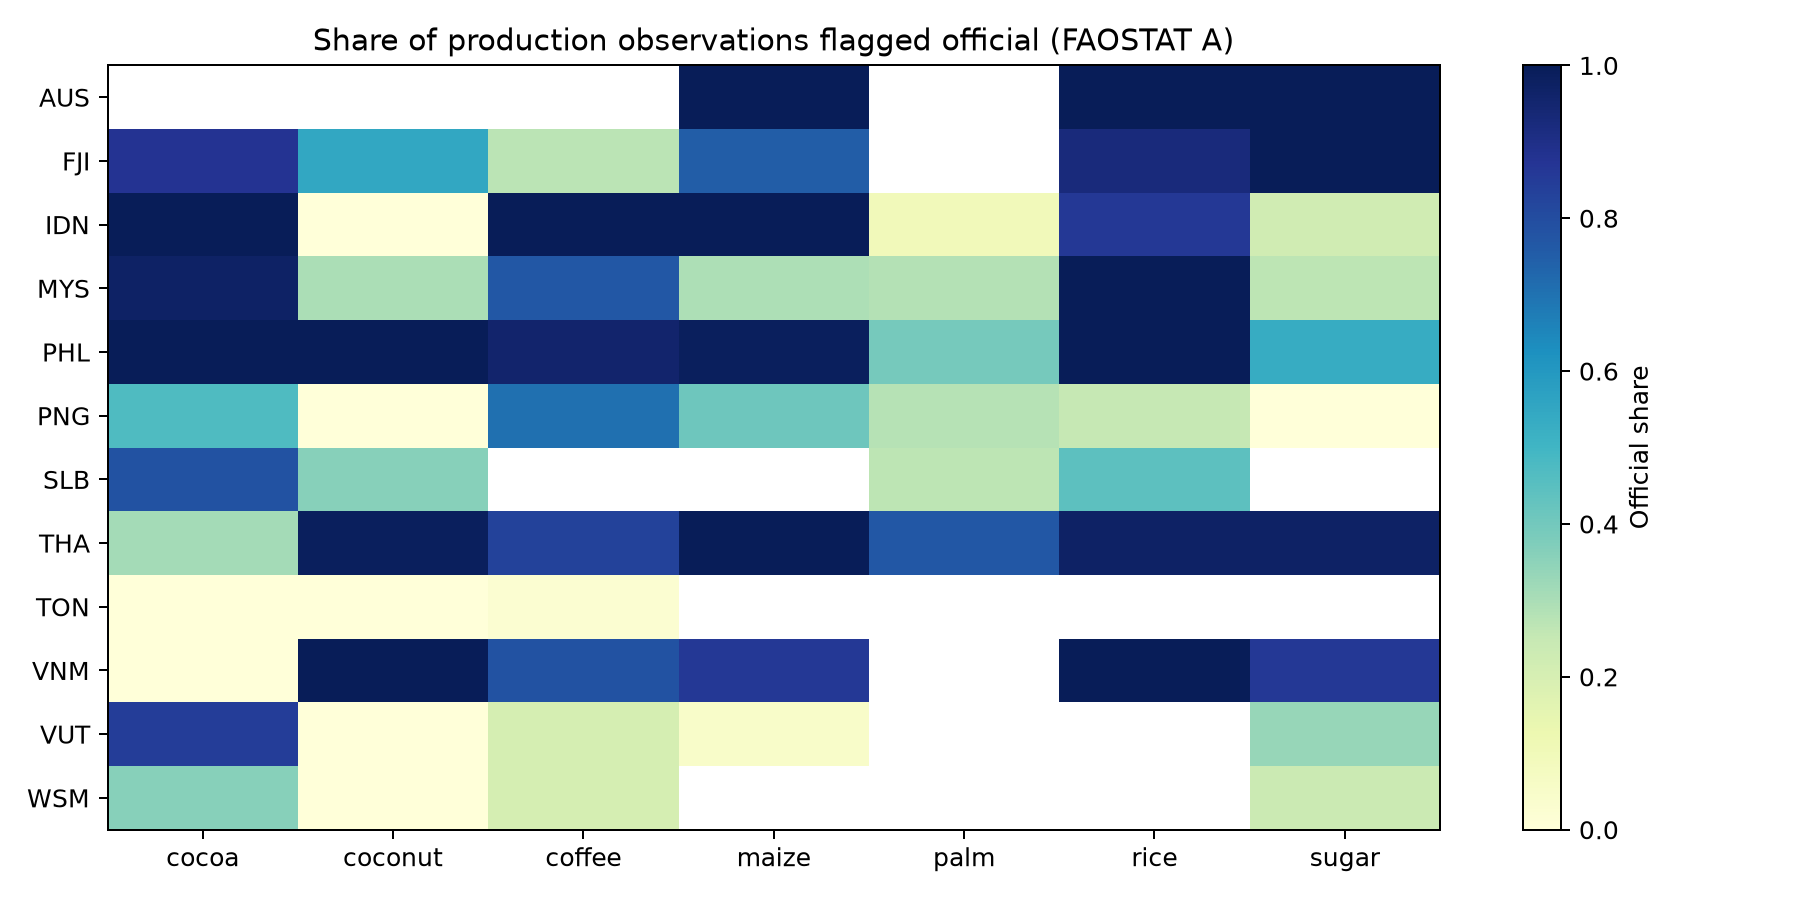

In [2]:
snapshot = json.loads((ROOT / 'data/processed/snapshot.json').read_text())
display(pd.DataFrame([{'source': k, 'rows': v} for k, v in snapshot['rows'].items()]))
coverage = pd.read_csv(ROOT / 'data/processed/coverage.csv')
display(coverage.groupby('evidence_grade').agg(series=('series','size'), eligible=('eligible','sum')))
display(Image(filename=str(REPORTS / 'figures/coverage.png')))


## 2. Historical weather and ENSO monitoring
The fitted weather specification uses national temperature, log rainfall, driest-month rain,
and hottest-month mean maximum temperature. These monthly measures are not daily heatwave counts.
The current ENSO forecast is a statistical AR/persistence benchmark, not an official CPC forecast.


,first,last,observations
variable,,,
pr,1901-01-01,2025-12-01,18000
tas,1901-01-01,2025-12-01,18000
tasmax,1901-01-01,2025-12-01,18000


{'as_of': '2026-09-07',
 'last_observed_center_month': '2026-07-01',
 'last_observed_index': 1.4,
 'index': 'roni',
 'selected_model': 'ar2',
 'one_step_rolling_rmse': {'ar2': 0.12479868102848175,
  'persistence': 0.21573517716558577},
 'forecast_paths': 2000,
 'current_exposure_year': 2026,
 'status': 'Statistical monitoring benchmark; not an official NOAA forecast',
 'limitations': 'Revised history; fixed AR coefficients; empirical residual blocks; multi-step probabilities not yet calibrated'}

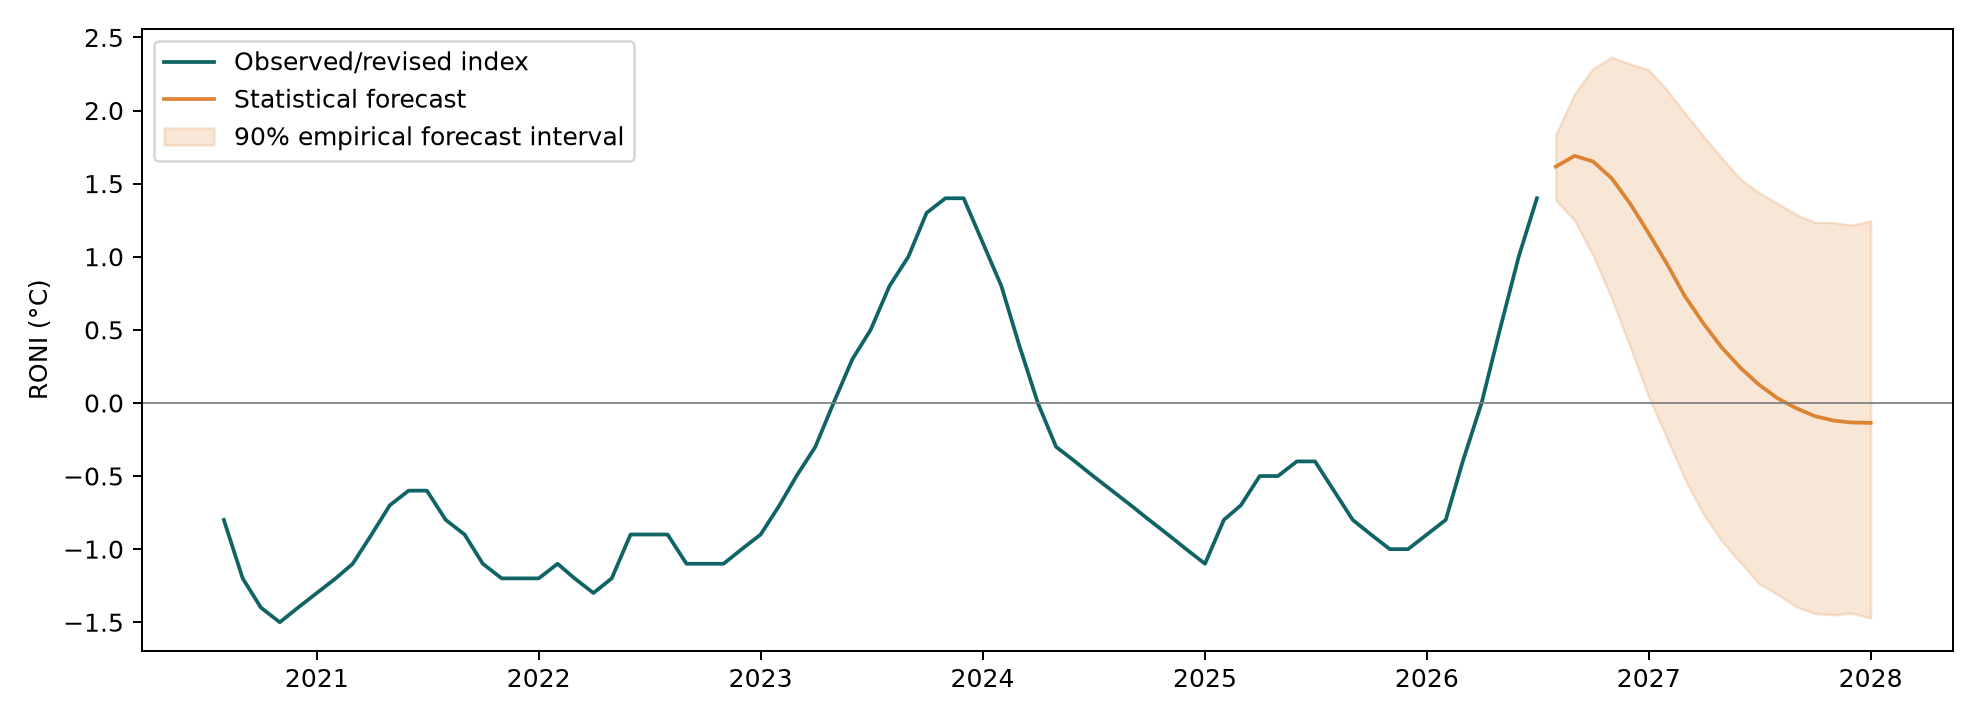

In [3]:
weather = pd.read_csv(ROOT / 'data/processed/weather.csv', parse_dates=['period'])
display(weather.groupby('variable').agg(first=('period','min'), last=('period','max'), observations=('value','size')))
display(json.loads((REPORTS / 'monitor.json').read_text()))
display(Image(filename=str(REPORTS / 'figures/outlook.png')))


## 3. Production, area, and phase comparisons
Annual log yield growth separates changes in productivity from harvested-area changes.
Phase buckets compare warm, cold, and neutral/mixed exposure years. They are analytical buckets,
not official event labels. Year-aggregated bootstrap intervals avoid treating every country row
as a separate ENSO realization, but serial dependence and confounding remain limitations.


In [4]:
display(pd.read_csv(REPORTS / 'phase_comparisons.csv'))
display(pd.read_csv(REPORTS / 'phase_contrasts.csv'))


,crop,phase,n,yield_growth,area_growth,temperature_c,annual_rain_mm
0,cocoa,El Nino,157,0.0117,0.0105,25.6691,"2,565.7766"
1,cocoa,La Nina,140,-0.0232,0.0333,25.7270,"2,939.3319"
2,cocoa,Neutral/mixed,242,0.0131,0.0237,25.6864,"2,749.8458"
3,coconut,El Nino,191,-0.0135,0.0029,25.5572,"2,381.6088"
4,coconut,La Nina,171,0.0128,-0.0214,25.5870,"2,714.2622"
5,coconut,Neutral/mixed,296,0.0151,0.0041,25.5919,"2,536.8975"
6,coffee,El Nino,172,0.0067,-0.0031,25.5203,"2,315.1838"
7,coffee,La Nina,155,0.0037,0.0184,25.5429,"2,692.5480"
8,coffee,Neutral/mixed,270,0.0259,0.0134,25.5382,"2,490.0704"
9,maize,El Nino,153,0.0029,-0.0094,24.8911,"2,074.0386"


,crop,phase,difference,lower90,upper90,phase_years,neutral_years
0,cocoa,El Nino,-0.0004,-0.0347,0.0326,18,28
1,cocoa,La Nina,-0.0348,-0.0687,-0.0013,16,28
2,coconut,El Nino,-0.0284,-0.0487,-0.0088,18,28
3,coconut,La Nina,-0.0017,-0.0252,0.0221,16,28
4,coffee,El Nino,-0.0175,-0.0510,0.0152,18,28
5,coffee,La Nina,-0.0222,-0.0549,0.0075,16,28
6,maize,El Nino,-0.0184,-0.0549,0.0176,18,28
7,maize,La Nina,-0.0012,-0.0315,0.0262,16,28
8,palm,El Nino,-0.0198,-0.0402,0.0022,18,28
9,palm,La Nina,0.0220,-0.0012,0.0433,16,28


## 4. Why hierarchical Bayesian modeling?
Country–crop ENSO slopes partially pool toward crop-level slopes. This supports small series without
assuming identical responses. Explicit priors regularize a problem with relatively few independent
extreme ENSO episodes. Posterior uncertainty remains conditional on the specification.

The main model uses asymmetric warm/cold effects, delayed warm effects, and lagged economic controls.
The weather specification investigates mediators, so it answers a different conditional question.
A neural network is a possible future spatial-data model, not a default substitute for careful validation.


In [5]:
model_diagnostics = json.loads((REPORTS / 'model_diagnostics.json').read_text())
display(pd.DataFrame(model_diagnostics))
display(json.loads((ROOT / 'artifacts/models/full/predictive_checks.json').read_text()) if (ROOT / 'artifacts/models/full/predictive_checks.json').exists() else 'See report for predictive checks')


,spec,n_observations,n_series,training_start,training_end,max_rhat,...,divergences,min_bfmi,diagnostics_pass,status,causal_identification,model
0,total,3793,63,1963,2024,1.0064,...,0,0.7860,True,research_candidate,False,full
1,total,3419,63,1963,2018,1.0074,...,0,0.7690,True,research_candidate,False,holdout2018
2,weather,3793,63,1963,2024,1.0053,...,0,0.8124,True,research_candidate,False,weather


{'observed_growth_sd': 0.16550890059914547,
 'posterior_predictive_sd': 0.16861401908913826,
 'in_sample_coverage90': 0.9140522014236752,
 'prior_predictive_growth_sd': 0.24830154478042168,
 'observed_abs_growth_above_0_5': 0.021618771421038754,
 'predicted_abs_growth_above_0_5': 0.01760670972844714,
 'interpretation': 'In-sample model checking; use chronological holdout for predictive validation'}

## 5. Does complexity improve prediction?
Chronological comparisons use matching observations. These are **conditional hindcasts** using
revised history and realized climate; they are not reconstructed real-time forecasts.
Inspect both point error and probabilistic scoring. A converged model can still have worse CRPS.


,model,n,mae,rmse,coverage90,interval_score90
0,economic_only,1532,0.0750,0.1511,0.9282,0.7516
1,enso,1532,0.0765,0.1520,0.9249,0.7438
2,historical_mean,1532,0.0722,0.1505,0.9360,0.7625
3,weather,1532,0.0767,0.1520,0.9236,0.7434


,model,phase,n,mae,rmse,coverage90,interval_score90
0,economic_only,El Nino,246,0.0883,0.1773,0.9187,0.9261
1,economic_only,La Nina,491,0.0726,0.1359,0.9287,0.6891
2,economic_only,Neutral/mixed,795,0.0723,0.1513,0.9308,0.7363
3,enso,El Nino,246,0.0859,0.1721,0.9146,0.8943
4,enso,La Nina,491,0.0759,0.1382,0.9287,0.6867
5,enso,Neutral/mixed,795,0.0739,0.1536,0.9258,0.7325
6,historical_mean,El Nino,246,0.0858,0.1867,0.9187,0.9669
7,historical_mean,La Nina,491,0.0680,0.1320,0.9369,0.6884
8,historical_mean,Neutral/mixed,795,0.0705,0.1486,0.9409,0.7450
9,weather,El Nino,246,0.0858,0.1723,0.9146,0.8952


{'n': 374,
 'rmse': 0.1284639985952034,
 'coverage90': 0.9438502673796791,
 'crps': 0.05857068204790171,
 'baseline_rmse': 0.13388330891210232,
 'baseline_crps': 0.05454630417543764,
 'baseline_coverage90': 0.9278074866310161,
 'training_cutoff': 2018,
 'interpretation': 'Revised-data conditional holdout, not real-time forecasting'}

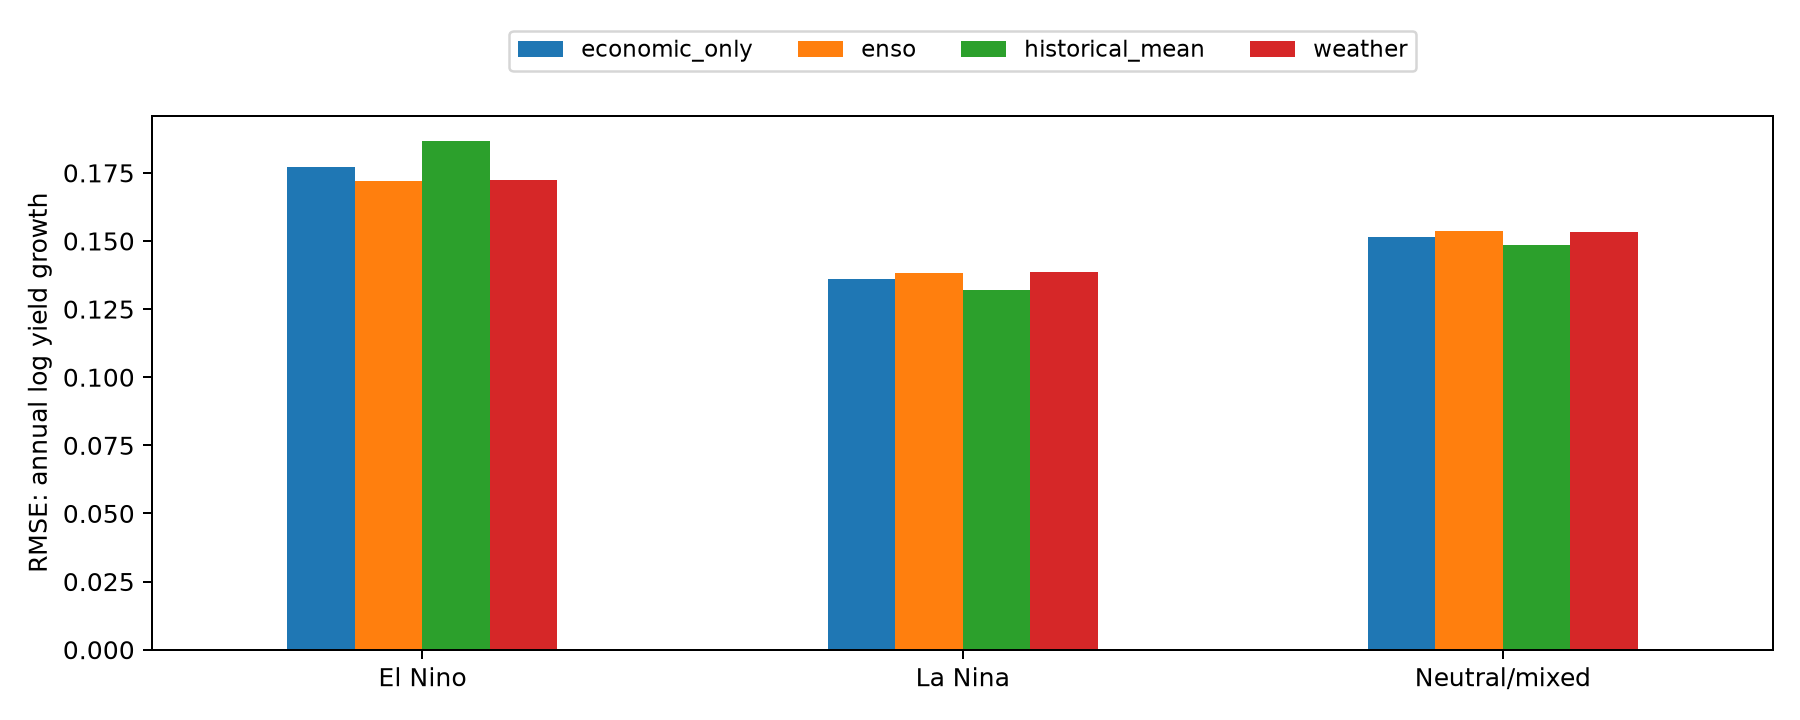

In [6]:
display(pd.read_csv(REPORTS / 'matched_metrics.csv'))
display(pd.read_csv(REPORTS / 'hindcast_metrics.csv'))
display(json.loads((REPORTS / 'bayesian_holdout_metrics.json').read_text()))
display(Image(filename=str(REPORTS / 'figures/validation.png')))


## 6. Stability and price channels
Compare matched series across index choice, official observations, and event exclusion.
Global benchmark prices are analyzed separately; processed-product prices must not be multiplied
by raw-crop tonnes. Local price support determines which price responses enter risk simulation.


In [7]:
robust = pd.read_csv(REPORTS / 'robustness.csv')
wide = robust.pivot(index='series', columns='variant', values='super_response_log_growth')
display(wide.head(20))
display(pd.read_csv(REPORTS / 'price_associations.csv'))
display(pd.read_csv(REPORTS / 'auxiliary_support.csv').groupby(['outcome','estimated']).size().rename('exposures'))


variant,all_records_roni,exclude_1982_83_and_neighbors,exclude_1997_98_and_neighbors,exclude_2015_16_and_neighbors,exclude_2023_24_and_neighbors,official_current_and_previous,oni_index
series,,,,,,,
AUS:maize,-0.0981,-0.0732,-0.0971,-0.0992,-0.0901,-0.0945,-0.1321
AUS:rice,-0.0419,-0.0369,-0.0949,-0.0233,-0.0396,-0.0408,-0.0493
AUS:sugar,-0.0325,-0.0374,-0.0441,-0.0207,-0.0366,-0.0335,-0.0465
FJI:cocoa,-0.0147,0.0414,-0.0284,-0.0983,-0.0167,-0.1911,0.1504
FJI:coconut,-0.0663,-0.0714,-0.0742,-0.0522,-0.0638,NaN,-0.0612
FJI:coffee,-0.1856,-0.2855,-0.2021,-0.1525,-0.1902,NaN,-0.1577
FJI:maize,0.1039,0.1156,0.0903,0.0783,0.1170,0.0590,0.0362
FJI:rice,-0.2618,-0.2688,-0.1946,-0.1911,-0.2643,-0.1847,-0.2896
FJI:sugar,-0.1585,-0.1284,-0.1565,-0.1299,-0.1643,-0.1647,-0.1722


,commodity,n_years,super_response_median_log_growth,lower90,upper90,interpretation
0,Cocoa,64,0.0959,-0.0547,0.2345,Unadjusted global price association; separate ...
1,Coconut oil,64,0.3403,0.1281,0.5521,Unadjusted global price association; separate ...
2,"Coffee, Robusta",64,0.0817,-0.0937,0.2743,Unadjusted global price association; separate ...
3,Maize,64,-0.0917,-0.2070,0.0157,Unadjusted global price association; separate ...
4,Palm oil,64,0.1933,0.0436,0.3208,Unadjusted global price association; separate ...
5,"Rice, Thai 5%",64,-0.0140,-0.1703,0.1490,Unadjusted global price association; separate ...
6,"Sugar, world",64,-0.1586,-0.4211,0.0925,Unadjusted global price association; separate ...


outcome       estimated
area_growth   True         47
price_growth  False        20
              True         27
Name: exposures, dtype: int64

## 7. Actuarial loss distributions
The baseline uses exact primary-crop values in 2024 nominal USD. Each simulation combines yield
posterior draws, bootstrapped area/local-price responses, and empirical shared-year residual shocks.
Fiscal capture is an **uncalibrated assumption**, shared within each country.

Climate increment compares paired scenario and neutral receipts. Baseline shortfall additionally
includes background variability. Gains can offset losses. Percentiles are conditional on a scenario;
no unconditional return periods or default probabilities are inferred.


,scenario,expected_net_loss_million_usd,var95_million_usd,es95_million_usd,probability_loss
20,neutral,0.0000,0.0000,0.0000,0.0000
42,el_nino,190.8694,387.2216,453.6942,0.9661
64,la_nina,-180.8834,81.7967,151.0902,0.1322
86,super_stress,485.1789,"1,004.3206","1,185.0677",0.9606
108,post_super,-156.2180,410.0516,572.0237,0.3311
130,current_statistical_outlook,106.8592,301.5828,373.6717,0.8523


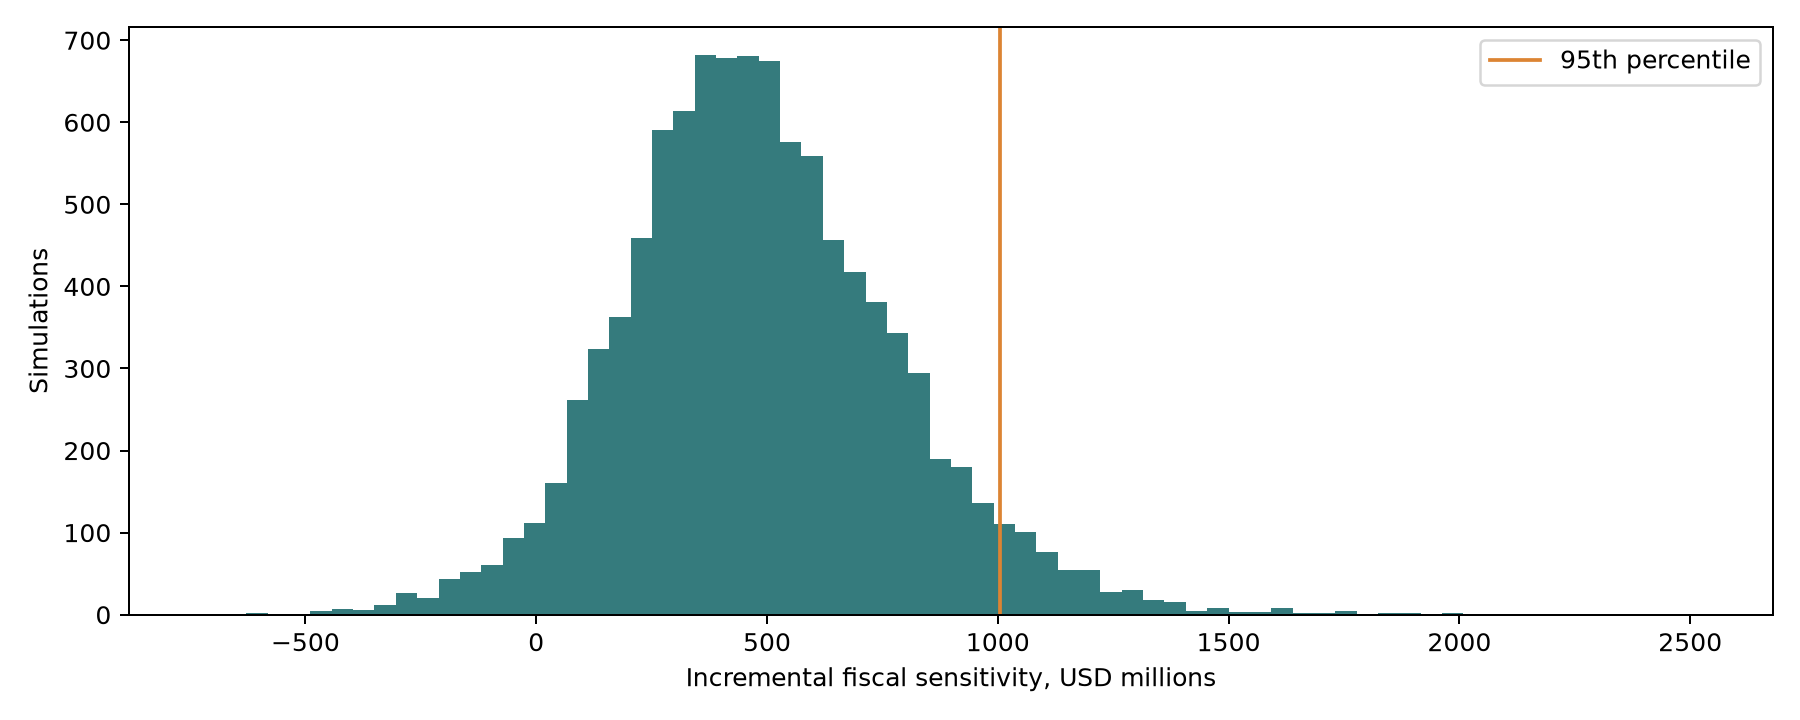

In [8]:
risk = pd.read_csv(REPORTS / 'risk_metrics.csv')
portfolio = risk[(risk.country == 'PORTFOLIO') & (risk.basis == 'climate_increment')].copy()
for col in ['expected_net_loss_usd','var95_usd','es95_usd']:
    portfolio[col.replace('_usd','_million_usd')] = portfolio[col] / 1e6
display(portfolio[['scenario','expected_net_loss_million_usd','var95_million_usd','es95_million_usd','probability_loss']])
display(Image(filename=str(REPORTS / 'figures/loss_distribution.png')))


## 8. Assumptions can dominate precision
Inspect capture-rate and dependence sensitivities. The rank-aligned case is an adverse dependence
stress, not a calibrated alternative. Missing recent valuations are excluded rather than fabricated.


In [9]:
display(pd.read_csv(REPORTS / 'fiscal_capture_sensitivity.csv'))
display(pd.read_csv(REPORTS / 'dependence_sensitivity.csv'))
display(pd.read_csv(REPORTS / 'excluded_exposures.csv'))
display(pd.read_csv(REPORTS / 'fiscal_denominators.csv'))


,fixed_capture_rate,expected_net_loss_usd,probability_loss,var95_usd,var99_usd,es95_usd,es99_usd,probability_buffer_exceeded,illustrative_layer_pure_premium_usd,illustrative_layer_loaded_premium_usd
0,0.0100,"90,678,442.6685",0.9615,"175,976,862.0981","217,202,844.1228","201,703,142.7452","241,813,342.1560",NaN,"91,572,241.6905","109,886,690.0286"
1,0.0500,"453,392,213.3424",0.9615,"879,884,310.4903","1,086,014,220.6139","1,008,515,713.7261","1,209,066,710.7800",NaN,"457,861,208.4525","549,433,450.1431"
2,0.1000,"906,784,426.6847",0.9615,"1,759,768,620.9806","2,172,028,441.2279","2,017,031,427.4522","2,418,133,421.5600",NaN,"915,722,416.9051","1,098,866,900.2861"


,dependence,expected_net_loss_usd,probability_loss,var95_usd,var99_usd,es95_usd,es99_usd,probability_buffer_exceeded,illustrative_layer_pure_premium_usd,illustrative_layer_loaded_premium_usd
0,shared_empirical_year,"485,178,900.5149",0.9606,"1,004,320,604.4301","1,275,652,395.2889","1,185,067,736.5411","1,484,230,814.7916",NaN,"490,420,633.6261","588,504,760.3513"
1,independent_marginals,"485,178,900.5149",0.9956,"819,660,197.7282","1,004,661,288.5672","946,243,707.1886","1,190,163,825.3893",NaN,"485,470,047.3555","582,564,056.8265"
2,rank_aligned_stress,"485,178,900.5149",0.8154,"1,539,247,756.2600","2,215,137,759.8224","1,964,105,545.0703","2,680,378,528.9691",NaN,"540,963,008.4851","649,155,610.1821"


,series,reason
0,FJI:coffee,No valuation in common latest baseline year
1,PNG:cocoa,No valuation in common latest baseline year
2,PNG:coconut,No valuation in common latest baseline year
3,PNG:coffee,No valuation in common latest baseline year
4,PNG:maize,No valuation in common latest baseline year
5,PNG:palm,No valuation in common latest baseline year
6,PNG:rice,No valuation in common latest baseline year
7,PNG:sugar,No valuation in common latest baseline year
8,SLB:cocoa,No valuation in common latest baseline year
9,SLB:coconut,No valuation in common latest baseline year


,country,fiscal_year,government_revenue_usd,reason
0,AUS,"2,022.0000","443,090,336,404.2623",Matched-year WDI revenue excluding grants; gov...
1,FJI,"2,024.0000","1,588,449,815.4786",Matched-year WDI revenue excluding grants; gov...
2,IDN,NaN,NaN,No matched GDP/revenue observations within two...
3,MYS,"2,024.0000","70,932,826,636.8398",Matched-year WDI revenue excluding grants; gov...
4,PHL,"2,024.0000","77,067,794,845.4124",Matched-year WDI revenue excluding grants; gov...
5,THA,"2,024.0000","107,126,981,289.9014",Matched-year WDI revenue excluding grants; gov...
6,TON,"2,023.0000","133,839,821.1018",Matched-year WDI revenue excluding grants; gov...
7,VNM,NaN,NaN,No matched GDP/revenue observations within two...
8,VUT,"2,023.0000","287,105,847.2536",Matched-year WDI revenue excluding grants; gov...
9,WSM,"2,023.0000","321,030,473.5766",Matched-year WDI revenue excluding grants; gov...


## 9. Findings and operation
Daily refresh support preserves immutable vintages, detects changed training inputs, and withholds
stale/failed risk estimates. It does not manufacture daily crop labels. A scheduled job must be enabled
separately on a host or in GitHub Actions. Read the findings below before interpreting the monetary outputs.


In [10]:
display(Markdown((REPORTS / 'FINDINGS.md').read_text()))

# Findings from the downloaded data

These are reproducible research findings from the source vintages listed in the report, not validated fiscal forecasts.

## Evidence coverage

- 63 eligible country–crop histories across 12 economies; 3,793 yield-growth modeling observations, 1963–2024.
- Historical weather includes monthly temperature, rainfall and mean maximum temperature through 2025.
- Only 47 crop exposures have matching 2024 monetary valuations. Papua New Guinea and Solomon Islands
  are absent from the valued portfolio because recent matching crop values are unavailable. Several other
  crops are also excluded; see `excluded_exposures.csv`.
- All 47 valued series support area-response regressions, but only 27 support local price-response estimation.
  The remaining 20 have a disclosed fixed-price sensitivity. Provider estimates and imputations remain flagged.

## Predictive performance is mixed

On 1,532 matching conditional hindcast observations from 2000–2024, the historical-mean baseline has
RMSE 0.1505, economic-controls ridge 0.1511, ENSO ridge 0.1520, and weather ridge 0.1521 (annual log yield growth).
ENSO ridge improves El Niño-year RMSE relative to economic-only ridge (0.1721 versus 0.1773), but this
does not translate into uniformly better performance across phases. The weather model has the lowest
aggregate interval score among these four benchmarks, by a small margin.

A separate Bayesian model fitted only through 2018 was evaluated on 374 observations in 2019–2024:

| Metric | Bayesian | Historical-mean baseline |
|---|---:|---:|
| RMSE | 0.1285 | 0.1339 |
| CRPS (lower is better) | 0.0586 | 0.0545 |
| 90% interval coverage | 94.4% | 92.8% |

The Bayesian model improves point error by 4.0%, but its CRPS is worse.
It has **not earned a claim of superior probabilistic forecasting**. These are revised-data conditional
holdouts using realized climate, not historical real-time forecasts. The latest crop label remains annual.

## Numerical model checks

The full model uses four chains with 1,000 retained draws each: maximum R-hat 1.0064, minimum bulk ESS
926.7, zero divergences, and minimum BFMI 0.786. The historical-cutoff fit also passes the configured gates.
In-sample posterior predictive dispersion is close to observed dispersion, but extreme growth frequencies
are somewhat underrepresented. Computational convergence does not remove model misspecification.

## Illustrative fiscal sensitivity, not an empirical loss forecast

Under the stylized super-stress feature vector and an **assumed** country-level triangular capture rate
of 1% / 5% / 10%, the included portfolio yields approximately:

- Mean incremental fiscal sensitivity: **$485 million**.
- Conditional 95th-percentile sensitivity: **$1,004 million**.
- Conditional 95% expected shortfall: **$1,185 million**.

These numbers use 2024 nominal gross crop values, incomplete country coverage, approximate cross-channel
uncertainty, and uncalibrated fiscal capture. They are not estimates of actual 2026 government losses,
sovereign default probabilities, or one-in-20-year return levels. Negative modeled losses in other
scenarios represent gains relative to the neutral comparison. Fiscal-rate and dependence sensitivity
tables show how structural assumptions affect the tails.

## What the project demonstrates

An auditable climate/agriculture panel, model comparisons across warm/cold/neutral conditions,
Bayesian partial pooling, chronological probabilistic evaluation, operational data vintages, and
transparent actuarial stress simulation. Its strongest current evidence is agricultural response analysis;
country-calibrated fiscal transmission and spatial crop-weather alignment remain necessary extensions.
